# Forest Plot Examples: ForestPlotter vs ClinicalForestPlotter

This notebook demonstrates the two forest plot options in bioviz-kit:

1. **ForestPlotter** - A general-purpose forest plot for hazard ratios with optional significance coloring
2. **ClinicalForestPlotter** - A publication-ready clinical forest plot with table annotations (Events/Patients, Medians, p-values)

Both plotters support extensive customization of markers, lines, colors, fonts, and layout.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from bioviz.configs import ClinicalForestPlotConfig, ForestPlotConfig

# Import both plotters and their configs
from bioviz.plots import ClinicalForestPlotter, ForestPlotter

## Mock Data

### Simple DataFrame for ForestPlotter

ForestPlotter requires minimal columns: HR, CI bounds, and labels.

In [2]:
# Simple data for ForestPlotter
df_simple = pd.DataFrame(
    {
        "subgroup": ["All Patients", "Age < 65", "Age >= 65", "Male", "Female", "ECOG 0", "ECOG 1"],
        "hr": [0.72, 0.68, 0.78, 0.70, 0.75, 0.65, 0.82],
        "ci_lower": [0.58, 0.48, 0.55, 0.52, 0.55, 0.45, 0.62],
        "ci_upper": [0.89, 0.96, 1.10, 0.94, 1.02, 0.94, 1.08],
        "p_value": [0.002, 0.028, 0.152, 0.015, 0.068, 0.022, 0.156],
    }
)

df_simple

,subgroup,hr,ci_lower,ci_upper,p_value
0,All Patients,0.72,0.58,0.89,0.002
1,Age < 65,0.68,0.48,0.96,0.028
2,Age >= 65,0.78,0.55,1.10,0.152
3,Male,0.70,0.52,0.94,0.015
4,Female,0.75,0.55,1.02,0.068
5,ECOG 0,0.65,0.45,0.94,0.022
6,ECOG 1,0.82,0.62,1.08,0.156


### Rich DataFrame for ClinicalForestPlotter

ClinicalForestPlotter can display additional clinical data: events/patients per arm, median survival, and p-values.

In [3]:
# Rich clinical data for ClinicalForestPlotter
df_clinical = pd.DataFrame(
    {
        # Row labels
        "display_label": ["All Patients", "Age < 65", "Age >= 65", "Male", "Female"],
        # Hazard ratio and confidence interval
        "hr": [0.72, 0.68, 0.78, 0.70, 0.75],
        "hr_ci_lower": [0.58, 0.48, 0.55, 0.52, 0.55],
        "hr_ci_upper": [0.89, 0.96, 1.10, 0.94, 1.02],
        # Reference arm (e.g., Treatment)
        "reference": [
            "Experimental",
            "Experimental",
            "Experimental",
            "Experimental",
            "Experimental",
        ],
        "events_per_reference_group": [145, 62, 83, 98, 47],
        "n_per_reference_group": [250, 108, 142, 165, 85],
        # Comparator arm (e.g., Control)
        "comparator": ["Control", "Control", "Control", "Control", "Control"],
        "events_per_comparator_group": [178, 75, 103, 118, 60],
        "n_per_comparator_group": [248, 105, 143, 162, 86],
        # Median survival for reference arm
        "median_surv_time_ref": [18.2, 20.1, 15.8, 17.5, 19.8],
        "median_surv_time_ref_ci_lower": [15.5, 16.2, 12.1, 14.2, 15.1],
        "median_surv_time_ref_ci_upper": [22.1, 25.3, 19.2, 21.8, 26.4],
        "median_surv_time_ref_not_reached": [False, False, False, False, False],
        "median_surv_time_ref_ci_lower_not_reached": [False, False, False, False, False],
        "median_surv_time_ref_ci_upper_not_reached": [False, False, False, False, True],
        # Median survival for comparator arm
        "median_surv_time_cmp": [12.4, 14.2, 10.8, 11.9, 13.5],
        "median_surv_time_cmp_ci_lower": [10.1, 11.5, 8.2, 9.5, 10.2],
        "median_surv_time_cmp_ci_upper": [14.8, 17.8, 13.5, 14.8, 17.1],
        "median_surv_time_cmp_not_reached": [False, False, False, False, False],
        "median_surv_time_cmp_ci_lower_not_reached": [False, False, False, False, False],
        "median_surv_time_cmp_ci_upper_not_reached": [False, False, False, False, False],
        # P-values
        "p_value_wald": [0.002, 0.028, 0.152, 0.015, 0.068],
    }
)

df_clinical

,display_label,hr,hr_ci_lower,hr_ci_upper,reference,events_per_reference_group,n_per_reference_group,comparator,events_per_comparator_group,n_per_comparator_group,...,median_surv_time_ref_not_reached,median_surv_time_ref_ci_lower_not_reached,median_surv_time_ref_ci_upper_not_reached,median_surv_time_cmp,median_surv_time_cmp_ci_lower,median_surv_time_cmp_ci_upper,median_surv_time_cmp_not_reached,median_surv_time_cmp_ci_lower_not_reached,median_surv_time_cmp_ci_upper_not_reached,p_value_wald
0,All Patients,0.72,0.58,0.89,Experimental,145,250,Control,178,248,...,False,False,False,12.4,10.1,14.8,False,False,False,0.002
1,Age < 65,0.68,0.48,0.96,Experimental,62,108,Control,75,105,...,False,False,False,14.2,11.5,17.8,False,False,False,0.028
2,Age >= 65,0.78,0.55,1.10,Experimental,83,142,Control,103,143,...,False,False,False,10.8,8.2,13.5,False,False,False,0.152
3,Male,0.70,0.52,0.94,Experimental,98,165,Control,118,162,...,False,False,False,11.9,9.5,14.8,False,False,False,0.015
4,Female,0.75,0.55,1.02,Experimental,47,85,Control,60,86,...,False,False,True,13.5,10.2,17.1,False,False,False,0.068


---
## 1. ForestPlotter Examples

### Basic ForestPlotter (defaults)

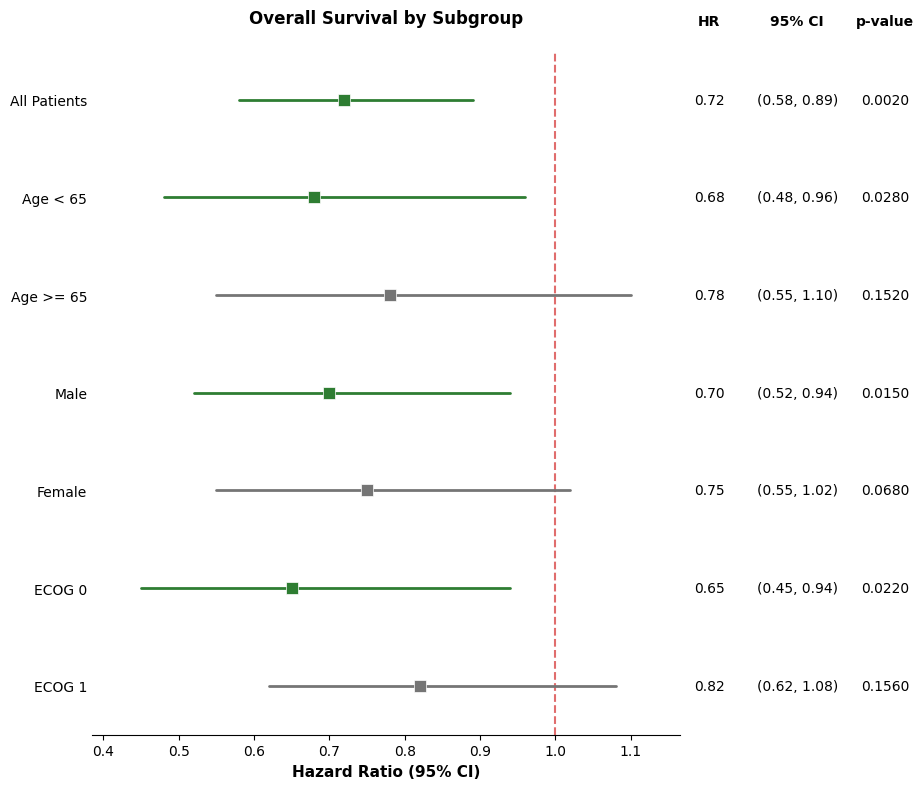

In [4]:
# Basic ForestPlotter with minimal config
config = ForestPlotConfig(
    hr_col="hr",
    ci_lower_col="ci_lower",
    ci_upper_col="ci_upper",
    label_col="subgroup",
    pvalue_col="p_value",
    title="Overall Survival by Subgroup",
    xlabel="Hazard Ratio (95% CI)",
)

plotter = ForestPlotter(df_simple, config)
fig, ax = plotter.plot()
plt.tight_layout()
plt.show()

### ForestPlotter with Customizations

Customize colors, markers, line styles, fonts, and more.

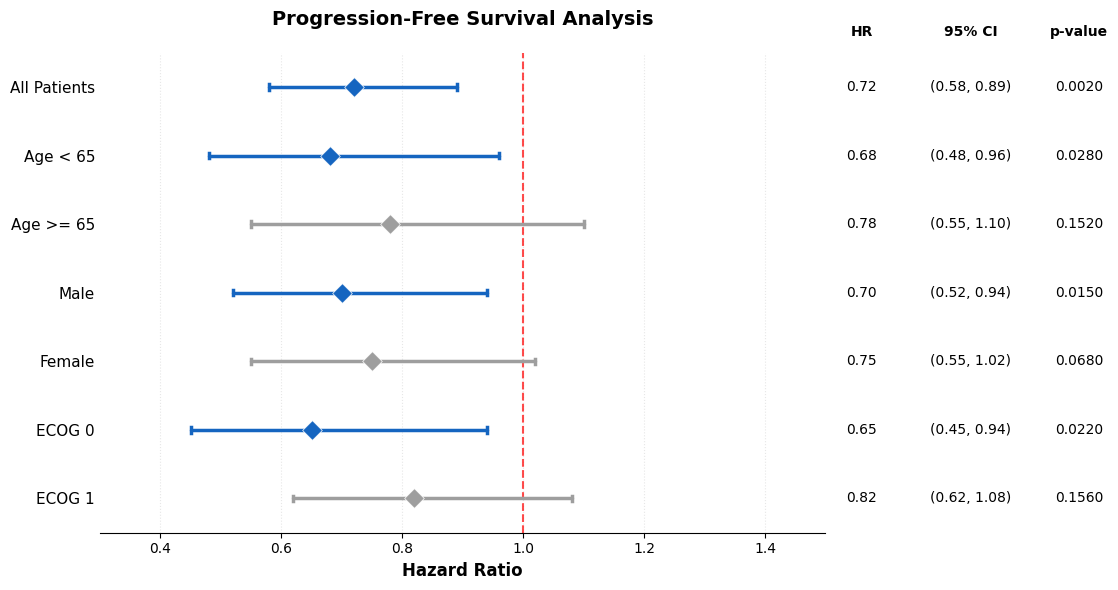

In [5]:
# Customized ForestPlotter
config_custom = ForestPlotConfig(
    # Column mapping
    hr_col="hr",
    ci_lower_col="ci_lower",
    ci_upper_col="ci_upper",
    label_col="subgroup",
    pvalue_col="p_value",
    # Title and labels
    title="Progression-Free Survival Analysis",
    xlabel="Hazard Ratio",
    # Figure size
    figsize=(12, 6),
    # Significance coloring
    color_significant="#1565C0",  # Blue for significant
    color_nonsignificant="#9E9E9E",  # Gray for non-significant
    alpha_threshold=0.05,
    # Marker customization
    marker_style="D",  # Diamond markers
    marker_size=10.0,
    # Error bar customization
    linewidth=2.5,
    show_caps=True,
    capsize=4.0,
    # Reference line at HR=1
    show_reference_line=True,
    reference_line_color="red",
    reference_line_style="--",
    reference_line_width=1.5,
    # X-axis
    xlim=(0.3, 1.5),
    log_scale=False,
    # Font sizes
    title_fontsize=14,
    ytick_fontsize=11,
    xtick_fontsize=10,
    xlabel_fontsize=12,
    # Grid
    show_grid=True,
)

plotter_custom = ForestPlotter(df_simple, config_custom)
fig, ax = plotter_custom.plot()
plt.tight_layout()
plt.show()

---
## 2. ClinicalForestPlotter Examples

### Basic ClinicalForestPlotter (defaults)

The clinical plotter automatically adds table columns for Events/Patients, HR, Medians, and p-values.

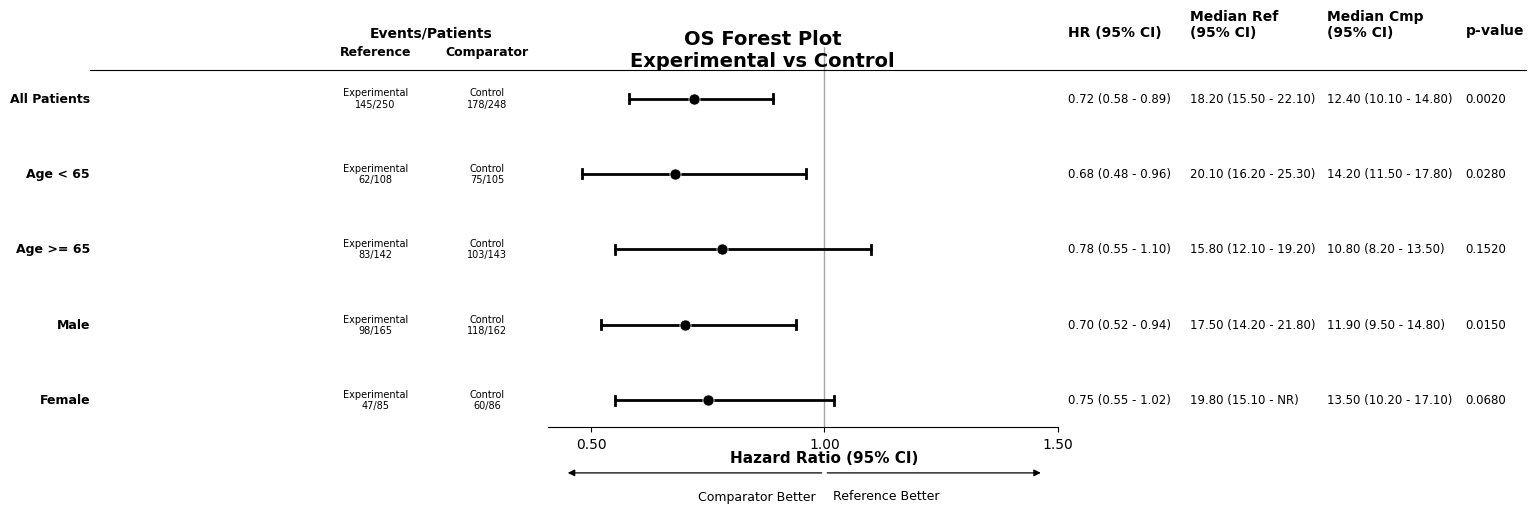

In [6]:
# Basic ClinicalForestPlotter with defaults
config_clinical = ClinicalForestPlotConfig(
    title="OS Forest Plot\nExperimental vs Control",
)

plotter_clinical = ClinicalForestPlotter(df_clinical, config_clinical)
fig, ax = plotter_clinical.plot()
plt.show()

### ClinicalForestPlotter with Full Customizations

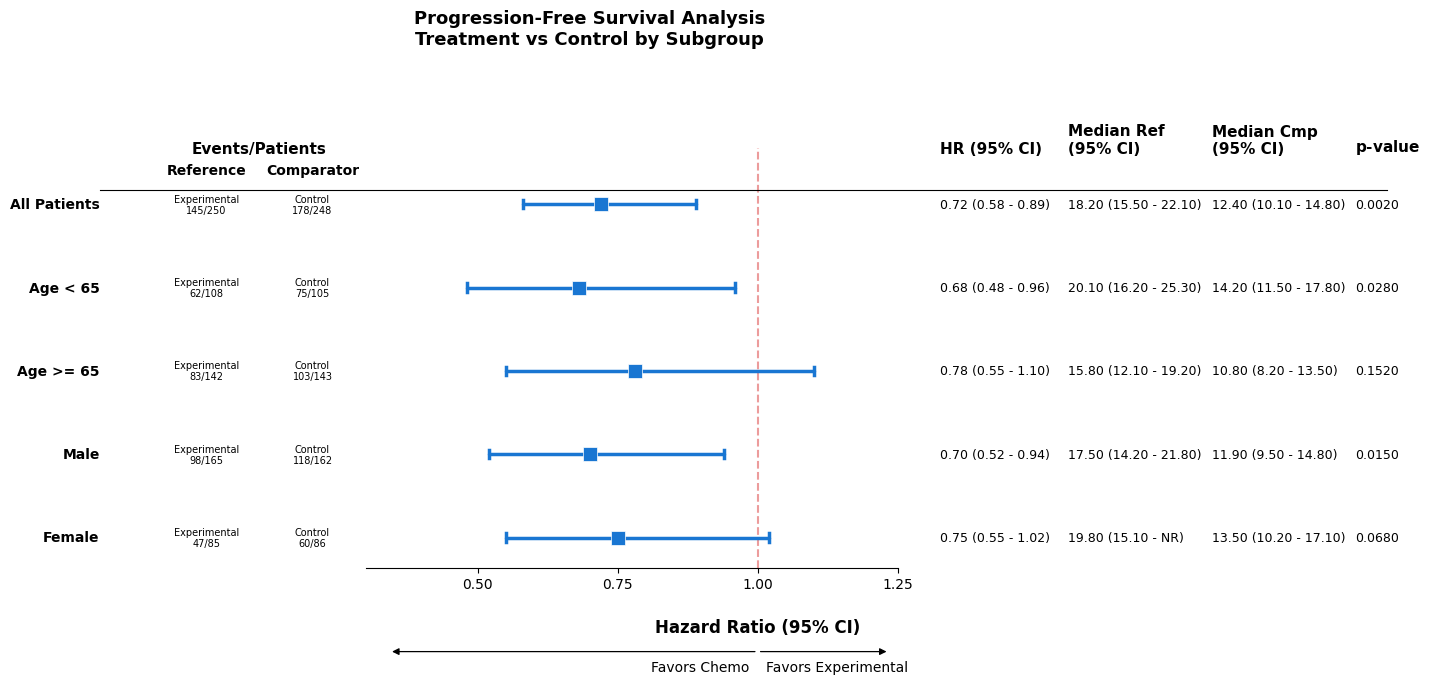

In [7]:
# Fully customized ClinicalForestPlotter
config_clinical_custom = ClinicalForestPlotConfig(
    # Title
    title="Progression-Free Survival Analysis\nTreatment vs Control by Subgroup",
    title_wrap_width=50,
    title_y_position=1.05,  # Title higher
    header_top_y=0.98,  # Headers lower (default 1.02)
    header_sub_y=0.93,  # Sub-headers lower (default 0.97)
    header_rule_end_x=1.92,  # X position where header rule line ends
    # Figure sizing
    figure_width=14.0,
    min_figure_height=5.0,
    row_height=0.5,
    # Table section visibility
    show_events_patients=True,
    show_hr_column=True,
    show_median_columns=True,
    show_pvalue_column=True,
    # Footer labels
    left_footer_label="Favors Chemo",
    right_footer_label="Favors Experimental",
    xlabel="Hazard Ratio (95% CI)",
    # X-axis
    xlim=(0.3, 1.25),
    xticks=[0.5, 0.75, 1.0, 1.25],
    # Reference line customization
    show_reference_line=True,
    reference_line_color="#E57373",  # Light red
    reference_line_style="--",
    reference_line_width=1.5,
    # Marker customization
    marker_style="s",  # Square markers
    marker_size=10.0,
    marker_color="#1976D2",  # Blue
    # Error bar customization
    linewidth=2.5,
    show_caps=True,
    capsize=5.0,
    # Font sizes
    title_fontsize=13.0,
    label_fontsize=10.0,
    header_fontsize=11.0,
    cell_fontsize=9.0,
    axis_fontsize=10.0,
    xlabel_fontsize=12.0,
    footer_fontsize=10.0,
    # Truncation markers for CIs that extend beyond xlim
    show_truncation_markers=True,
    # Footer customization
    footer_xlabel_offset=-0.12,  # default -0.06
    footer_arrow_offset=-0.20,  # default -0.12
    footer_text_offset=-0.22,  # default -0.165
    # stats table x positioning
    hr_x_position=1.08,  # Move HR further right (default 1.02)
    median_ref_x_position=1.32,
    median_cmp_x_position=1.59,
    pvalue_x_position=1.86,
    # Row label position
    label_x_position=-0.50,
    reference_x_position=-0.3,
    comparator_x_position=-0.1,
)

plotter_clinical_custom = ClinicalForestPlotter(df_clinical, config_clinical_custom)
fig, ax = plotter_clinical_custom.plot()
plt.show()

### ClinicalForestPlotter - Minimal Table (Hide Columns)

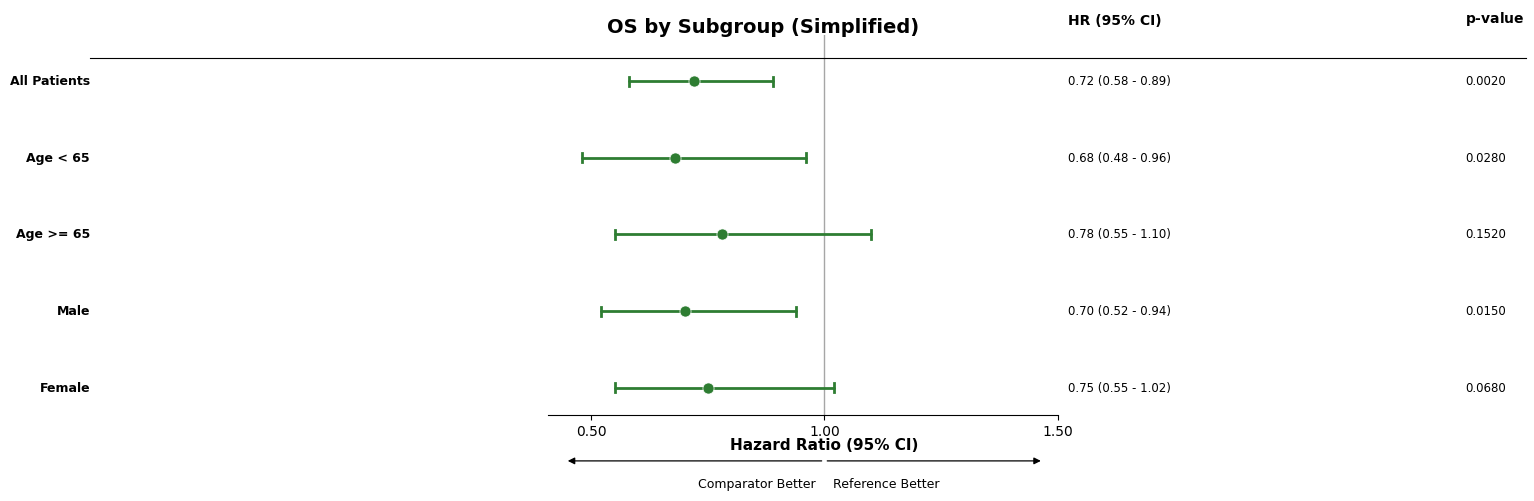

In [8]:
# Hide some table columns for a cleaner look
config_minimal = ClinicalForestPlotConfig(
    title="OS by Subgroup (Simplified)",
    # Hide median columns and events/patients
    show_events_patients=False,
    show_median_columns=False,
    show_hr_column=True,
    show_pvalue_column=True,
    # Styling
    marker_color="#2E7D32",  # Green
    marker_style="o",
)

plotter_minimal = ClinicalForestPlotter(df_clinical, config_minimal)
fig, ax = plotter_minimal.plot()
plt.show()

---
## 3. Side-by-Side Comparison

Compare ForestPlotter (simple) vs ClinicalForestPlotter (table-style) on the same data.

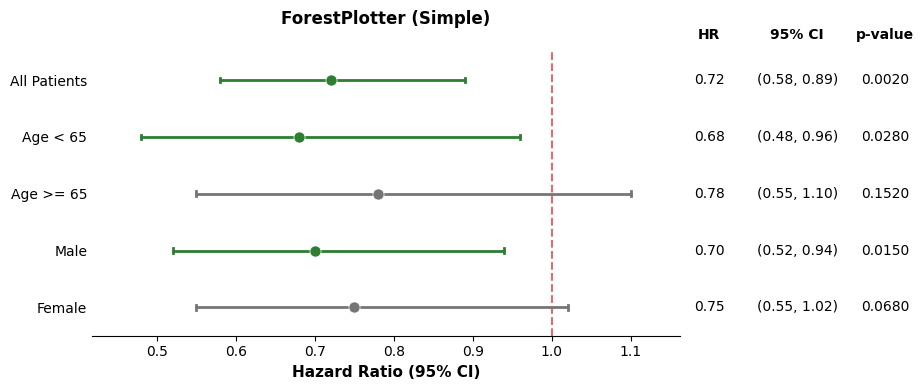

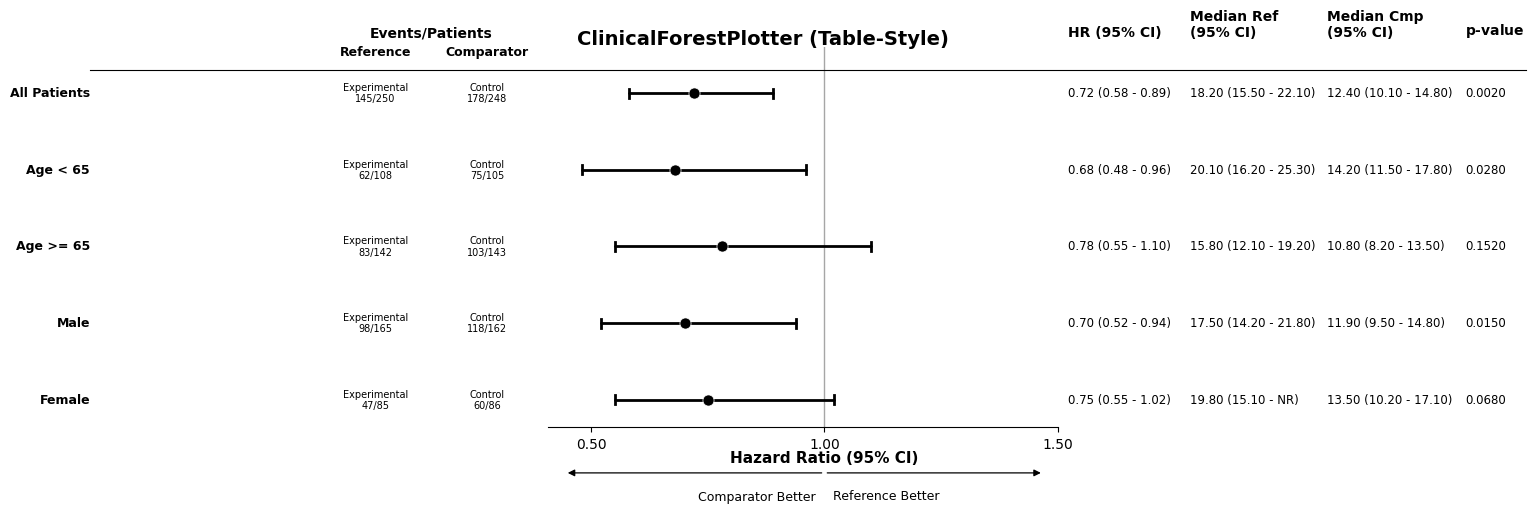

In [9]:
# Prepare simple data from clinical data for ForestPlotter
df_for_comparison = df_clinical[
    ["display_label", "hr", "hr_ci_lower", "hr_ci_upper", "p_value_wald"]
].rename(
    columns={
        "display_label": "subgroup",
        "hr_ci_lower": "ci_lower",
        "hr_ci_upper": "ci_upper",
        "p_value_wald": "p_value",
    }
)

# ForestPlotter (simple)
config_fp = ForestPlotConfig(
    hr_col="hr",
    ci_lower_col="ci_lower",
    ci_upper_col="ci_upper",
    label_col="subgroup",
    pvalue_col="p_value",
    figsize=(10, 4),
    title="ForestPlotter (Simple)",
    marker_style="o",
    show_caps=True,
    capsize=4,
)
plotter_fp = ForestPlotter(df_for_comparison, config_fp)
fig1, ax1 = plotter_fp.plot()
plt.tight_layout()
plt.show()

# ClinicalForestPlotter (table-style)
# Note: ClinicalForestPlotter creates its own figure due to complex layout requirements
config_cfp = ClinicalForestPlotConfig(
    title="ClinicalForestPlotter (Table-Style)",
)
plotter_cfp = ClinicalForestPlotter(df_clinical, config_cfp)
fig2, ax2 = plotter_cfp.plot()
plt.show()

---
## Summary: Key Differences

| Feature | ForestPlotter | ClinicalForestPlotter |
|---------|--------------|----------------------|
| **Use Case** | General HR visualization | Publication-ready clinical trials |
| **Table Columns** | None (just plot) | Events/Patients, HR, Medians, p-values |
| **Significance Coloring** | Yes (configurable) | No (single color) |
| **Auto Layout** | Manual sizing | Auto row height, margins, wrapping |
| **Truncation Markers** | No | Yes (for clipped CIs) |
| **Footer Arrows** | No | Yes (directional labels) |

### Common Customizations (Both Plotters)

- `marker_style`: "o", "s", "D", "^", etc.
- `marker_size`: float (default 8.0)
- `linewidth`: error bar thickness
- `show_caps` / `capsize`: error bar end caps
- `reference_line_color`, `reference_line_style`, `reference_line_width`
- `xlim`, `xticks`: x-axis control
- Various font size options